In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path to dataset files: /kaggle/input/vegetable-image-dataset


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} GPU(s)")
    for gpu in gpus:
        print(f"  Device name: {gpu.name}")
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU available. TensorFlow will use CPU.")


GPU available: 1 GPU(s)
  Device name: /physical_device:GPU:0


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Assuming the dataset structure is 'path/train' and 'path/test'
dataset_path = os.path.join(path, 'Vegetable Images')
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Define image dimensions and batch size
img_height, img_width = 224, 224 # InceptionV3 expects at least 75x75, 224x224 is common
batch_size = 32

# Image Data Generators for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")


Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Number of classes: 15


In [ ]:
# Load InceptionV3 base model with pre-trained ImageNet weights
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the convolutional layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x) # A dense layer with ReLU activation
predictions = Dense(num_classes, activation='softmax')(x) # Output layer for classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 23,916,335 (91.23 MB)

 Trainable params: 2,113,551 (8.06 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Train the model
epochs = 20 # You can adjust the number of epochs
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    verbose=1
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 315s 635ms/step - accuracy: 0.9259 - loss: 0.2802 - val_accuracy: 0.9773 - val_loss: 0.0748
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 431ms/step - accuracy: 0.9777 - loss: 0.0773 - val_accuracy: 0.9860 - val_loss: 0.0498
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 439ms/step - accuracy: 0.9847 - loss: 0.0511 - val_accuracy: 0.9840 - val_loss: 0.0563
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 435ms/step - accuracy: 0.9877 - loss: 0.0418 - val_accuracy: 0.9940 - val_loss: 0.0279
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 437ms/step - accuracy: 0.9885 - loss: 0.0379 - val_accuracy: 0.9913 - val_loss: 0.0287
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 432ms/step - accuracy: 0.9884 - loss: 0.0345 - val_accuracy: 0.9930 - val_loss: 0.0250
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 437ms/step - accuracy: 0.9917 - loss: 0.0272 - val_accuracy: 0.9947 - val_loss: 0.0217
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 262s 437ms/step - accuracy: 0.9892 -

In [ ]:
print("\n--- Training Summary ---")

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Get the last epoch's training accuracy and loss
last_train_accuracy = history.history['accuracy'][-1]
last_train_loss = history.history['loss'][-1]
print(f"Last Epoch Training Loss: {last_train_loss:.4f}")
print(f"Last Epoch Training Accuracy: {last_train_accuracy:.4f}")

print("\n--- Detailed History ---")
print(history.history)



--- Training Summary ---
Validation Loss: 0.0142
Validation Accuracy: 0.9950
Last Epoch Training Loss: 0.0209
Last Epoch Training Accuracy: 0.9929

--- Detailed History ---
{'accuracy': [0.9258666634559631, 0.977733314037323, 0.9847333431243896, 0.9877333045005798, 0.9885333180427551, 0.9883999824523926, 0.9916666746139526, 0.9891999959945679, 0.9932666420936584, 0.9918666481971741, 0.9908000230789185, 0.9941999912261963, 0.9939333200454712, 0.9934666752815247, 0.9926666617393494, 0.9927999973297119, 0.9942666888237, 0.9933333396911621, 0.994866669178009, 0.9929333329200745], 'loss': [0.2802008390426636, 0.07730881869792938, 0.05112762376666069, 0.041833147406578064, 0.037919994443655014, 0.034542713314294815, 0.027186118066310883, 0.03512962535023689, 0.022197766229510307, 0.025290459394454956, 0.028125980868935585, 0.0191084835678339, 0.017809325829148293, 0.020077858120203018, 0.023510362952947617, 0.020997459068894386, 0.01812737248837948, 0.019689803943037987, 0.01541475858539342

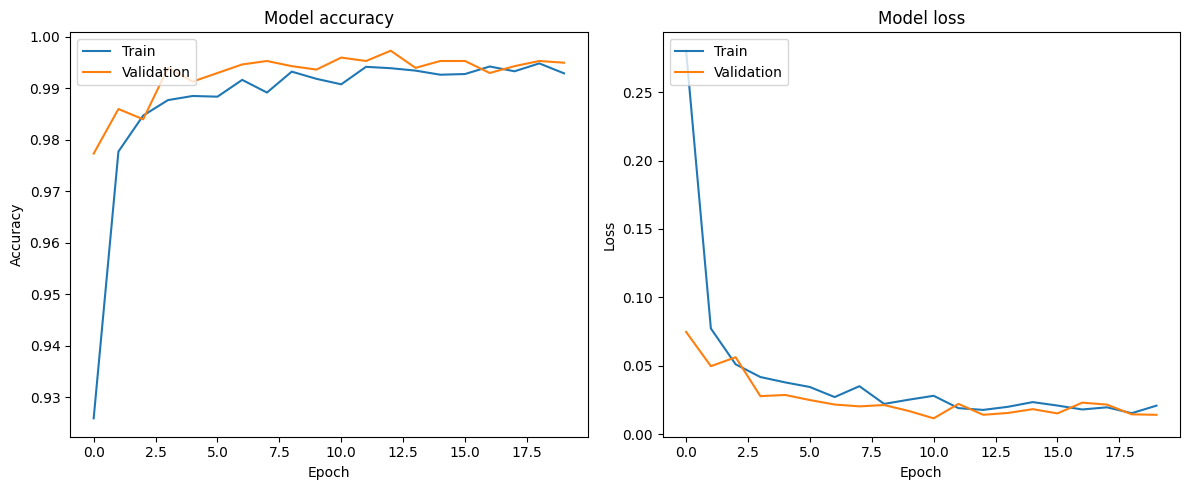

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()
